In [196]:
import numpy as numpy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [197]:
#load data
df=pd.read_csv("application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [198]:
#type of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [199]:
#checking for missing values and there are lots of missing values
df.isnull().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [200]:
#top 10 missing values
missing=(df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print(missing.head(10))

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64


In [201]:
#checking for duplicates values
df.duplicated().sum()

np.int64(0)

In [202]:
#describe data
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [203]:
#all the columns
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [204]:
#one by one all the columns
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [205]:
#unique values in target

df["TARGET"].unique()

array([1, 0])

In [206]:
#in target column 0 means the person is not defaulter and 1 means the person is defaulter
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [207]:
#percentage of defaulter and non defaulter
df["TARGET"].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [208]:
#how many rows and columns
df.shape

(307511, 122)

In [209]:
#checking for missing values
df["TARGET"].value_counts(dropna=False)

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [210]:
#describe target column
df["TARGET"].describe()

count    307511.000000
mean          0.080729
std           0.272419
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: TARGET, dtype: float64

<Axes: xlabel='TARGET'>

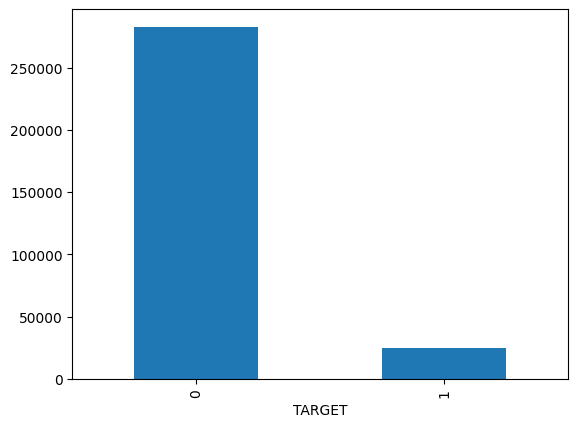

In [211]:
#plotting the target column
df["TARGET"].value_counts().plot(kind="bar")

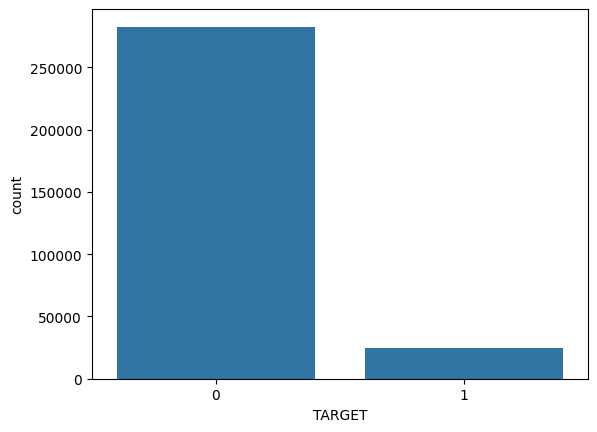

In [212]:
sns.countplot(x="TARGET",data=df)
plt.show()

In [213]:
df["NAME_CONTRACT_TYPE"].value_counts()

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

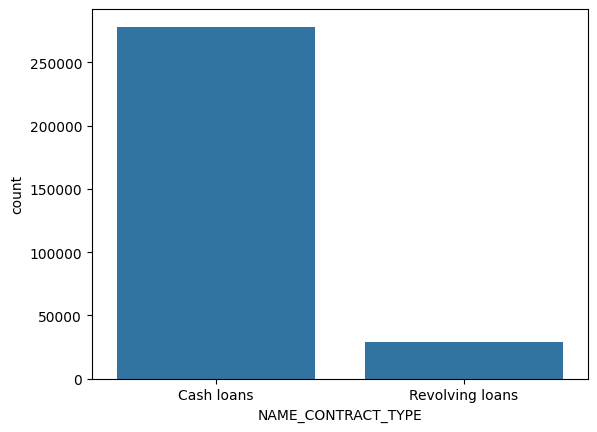

In [214]:
sns.countplot(x="NAME_CONTRACT_TYPE",data=df)
plt.show()

In [215]:
pd.crosstab(df["NAME_CONTRACT_TYPE"],df["TARGET"])

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,255011,23221
Revolving loans,27675,1604



Columns : CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


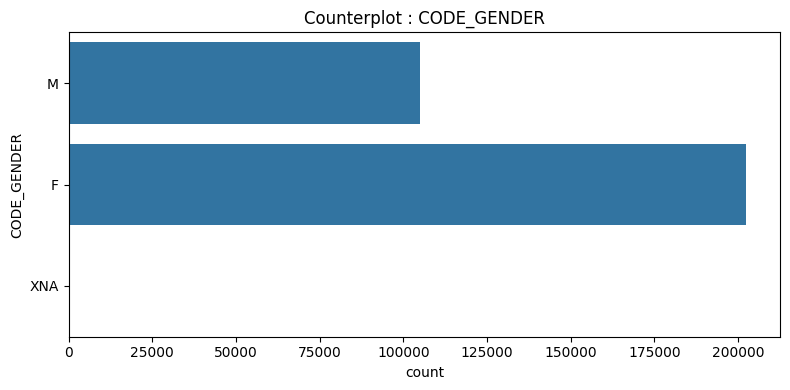

Relation with TARGET 
CODE_GENDER
F       7.00
M      10.14
XNA     0.00
Name: 1, dtype: float64


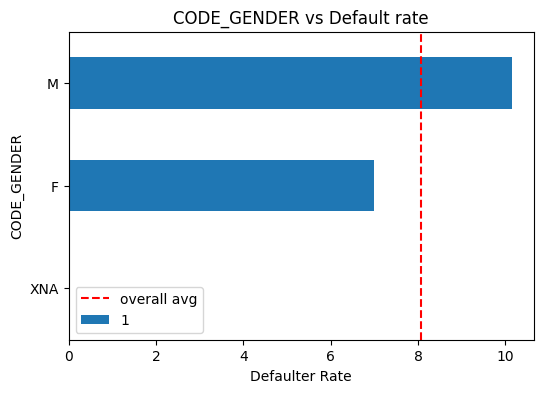


Columns : NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64


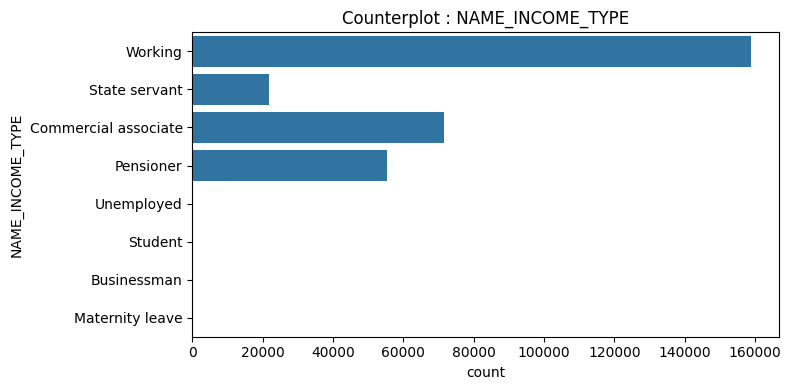

Relation with TARGET 
NAME_INCOME_TYPE
Businessman              0.00
Commercial associate     7.48
Maternity leave         40.00
Pensioner                5.39
State servant            5.75
Student                  0.00
Unemployed              36.36
Working                  9.59
Name: 1, dtype: float64


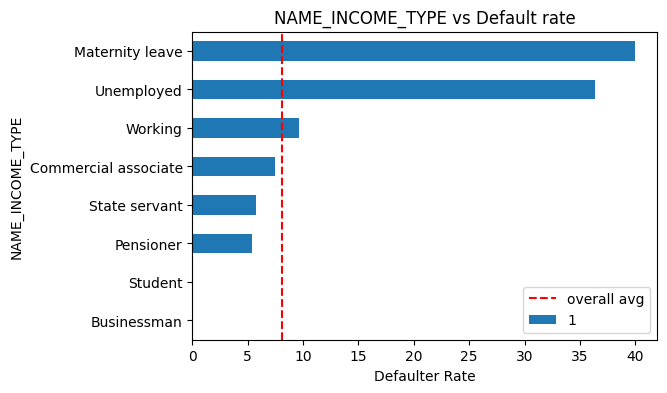


Columns : NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64


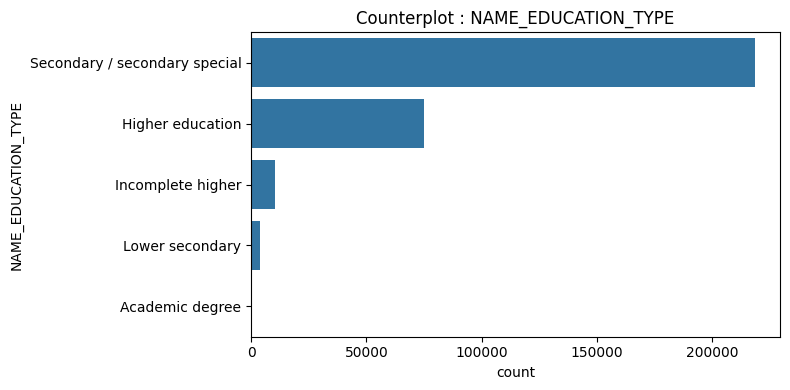

Relation with TARGET 
NAME_EDUCATION_TYPE
Academic degree                   1.83
Higher education                  5.36
Incomplete higher                 8.48
Lower secondary                  10.93
Secondary / secondary special     8.94
Name: 1, dtype: float64


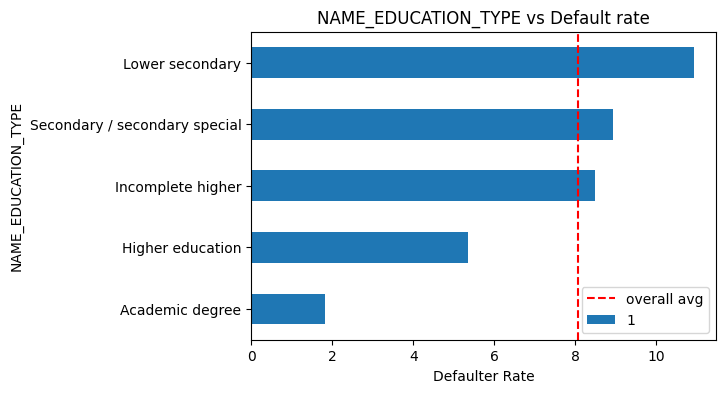


Columns : NAME_FAMILY_STATUS
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64


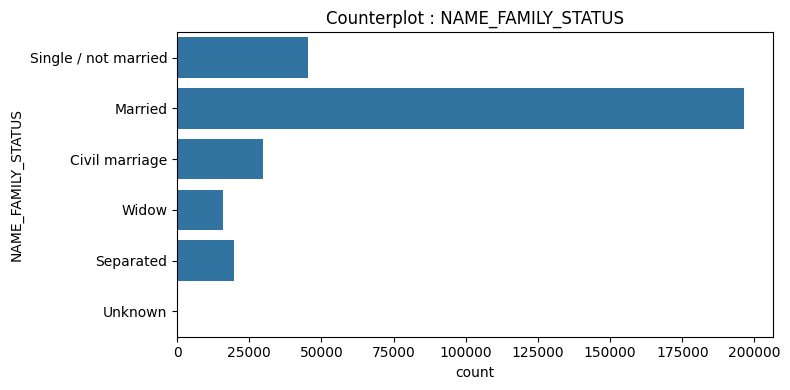

Relation with TARGET 
NAME_FAMILY_STATUS
Civil marriage          9.94
Married                 7.56
Separated               8.19
Single / not married    9.81
Unknown                 0.00
Widow                   5.82
Name: 1, dtype: float64


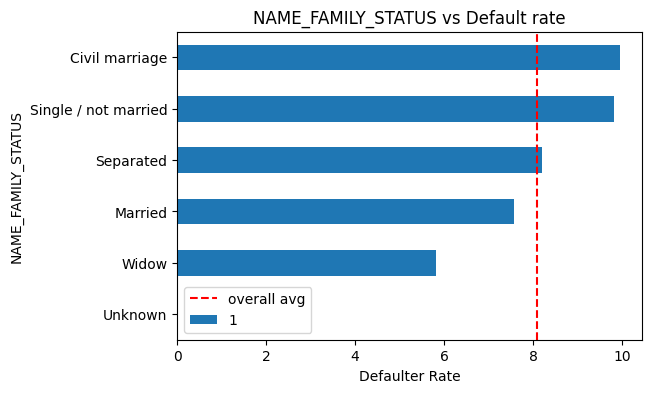


Columns : NAME_HOUSING_TYPE
NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64


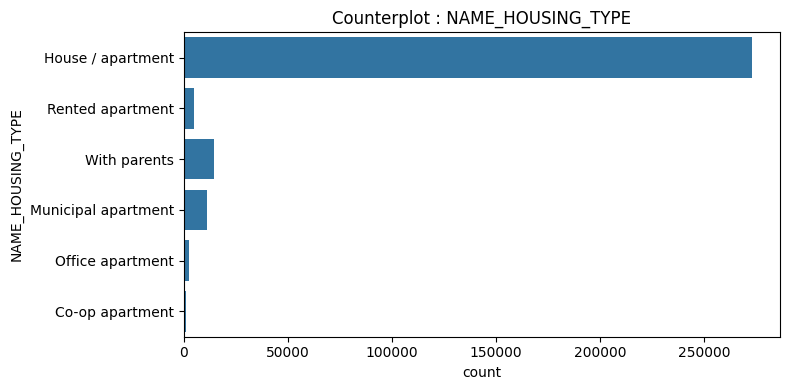

Relation with TARGET 
NAME_HOUSING_TYPE
Co-op apartment         7.93
House / apartment       7.80
Municipal apartment     8.54
Office apartment        6.57
Rented apartment       12.31
With parents           11.70
Name: 1, dtype: float64


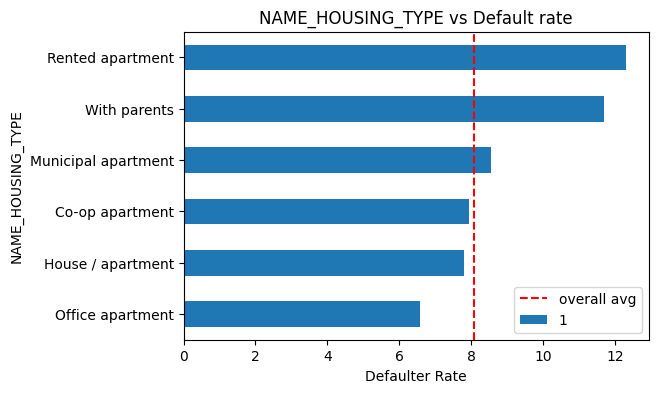


Columns : OCCUPATION_TYPE
OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64


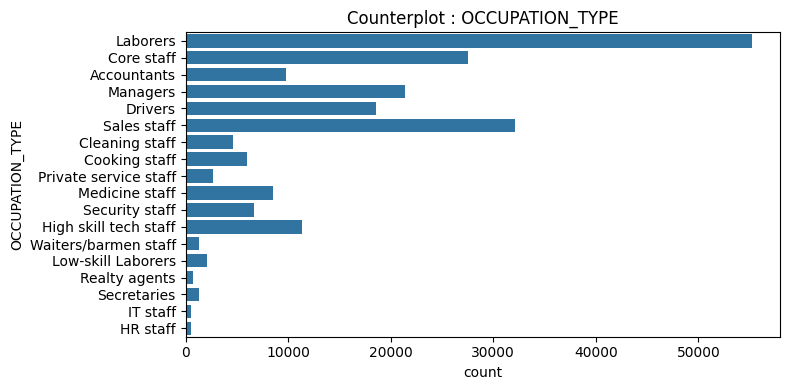

Relation with TARGET 
OCCUPATION_TYPE
Accountants               4.83
Cleaning staff            9.61
Cooking staff            10.44
Core staff                6.30
Drivers                  11.33
HR staff                  6.39
High skill tech staff     6.16
IT staff                  6.46
Laborers                 10.58
Low-skill Laborers       17.15
Managers                  6.21
Medicine staff            6.70
Private service staff     6.60
Realty agents             7.86
Sales staff               9.63
Secretaries               7.05
Security staff           10.74
Waiters/barmen staff     11.28
Name: 1, dtype: float64


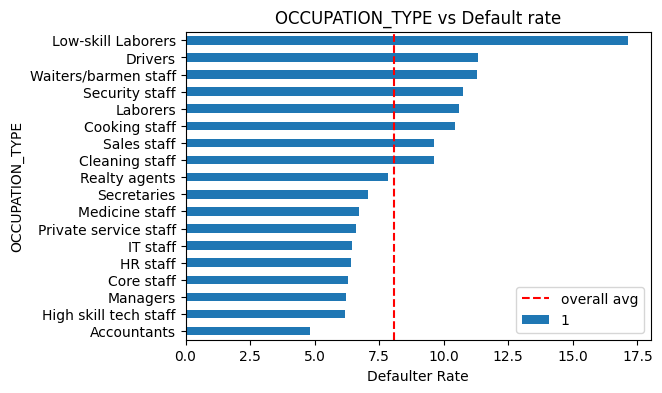


Columns : NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64


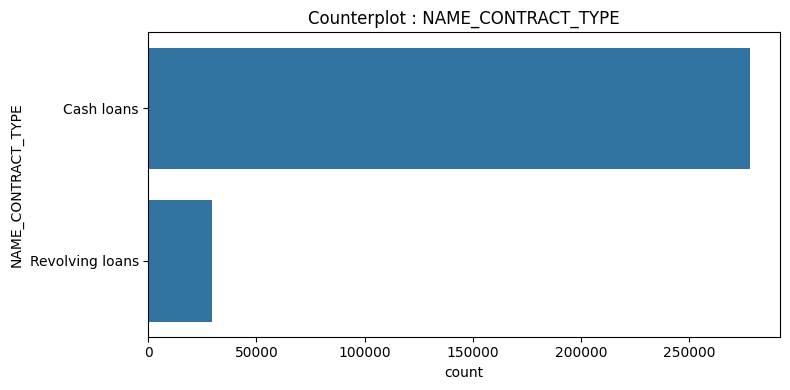

Relation with TARGET 
NAME_CONTRACT_TYPE
Cash loans         8.35
Revolving loans    5.48
Name: 1, dtype: float64


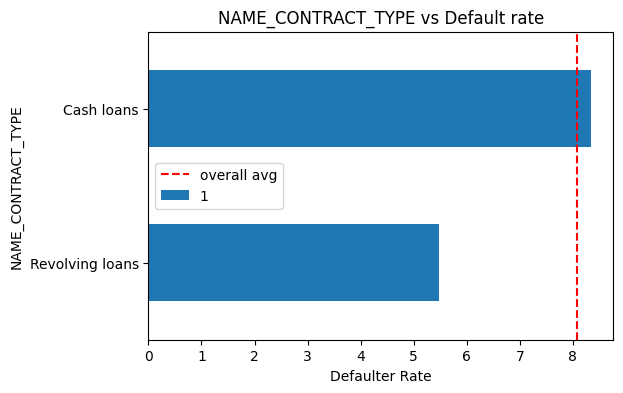


Columns : FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64


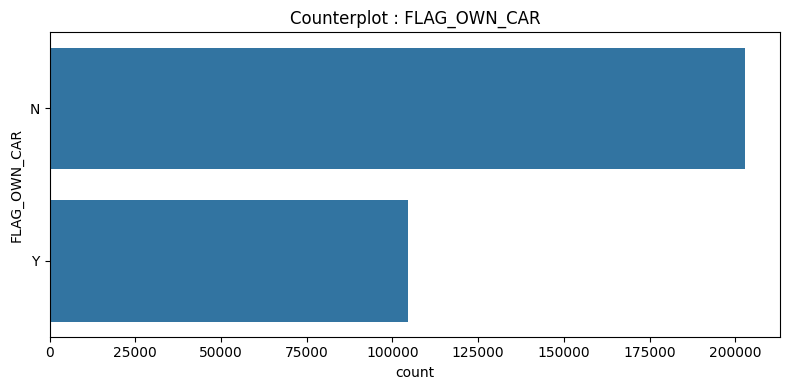

Relation with TARGET 
FLAG_OWN_CAR
N    8.50
Y    7.24
Name: 1, dtype: float64


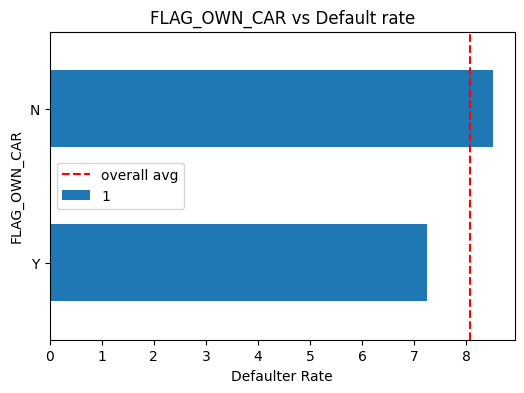


Columns : FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64


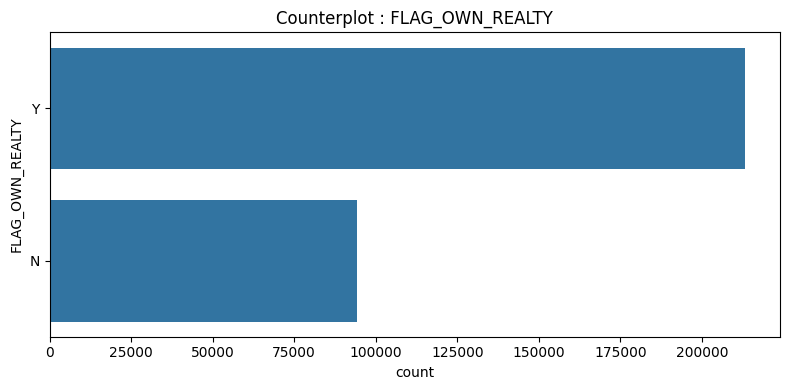

Relation with TARGET 
FLAG_OWN_REALTY
N    8.32
Y    7.96
Name: 1, dtype: float64


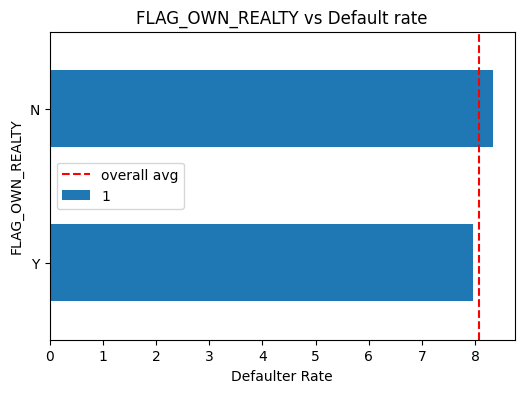


Columns : FLAG_EMP_PHONE
FLAG_EMP_PHONE
1    252125
0     55386
Name: count, dtype: int64


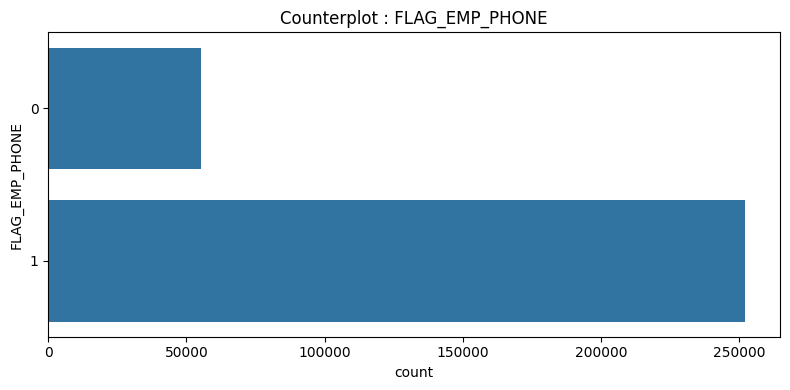

Relation with TARGET 
FLAG_EMP_PHONE
0    5.40
1    8.66
Name: 1, dtype: float64


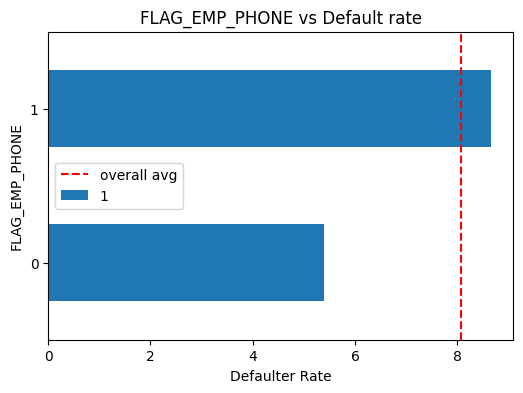


Columns : FLAG_PHONE
FLAG_PHONE
0    221080
1     86431
Name: count, dtype: int64


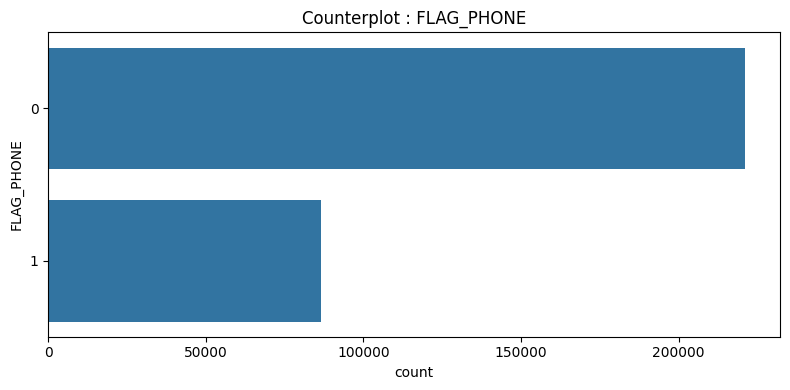

Relation with TARGET 
FLAG_PHONE
0    8.48
1    7.04
Name: 1, dtype: float64


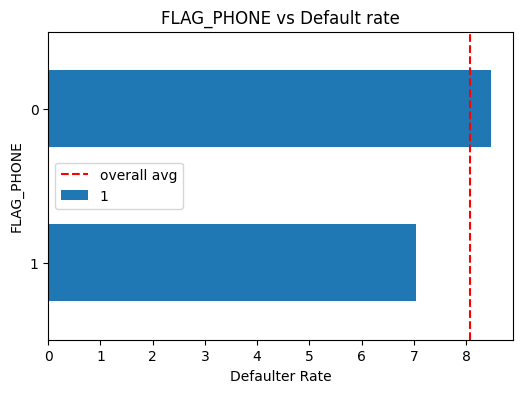


Columns : FLAG_EMAIL
FLAG_EMAIL
0    290069
1     17442
Name: count, dtype: int64


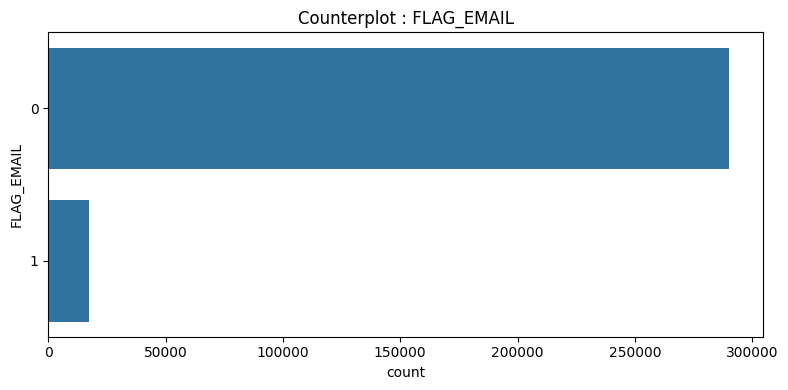

Relation with TARGET 
FLAG_EMAIL
0    8.08
1    7.88
Name: 1, dtype: float64


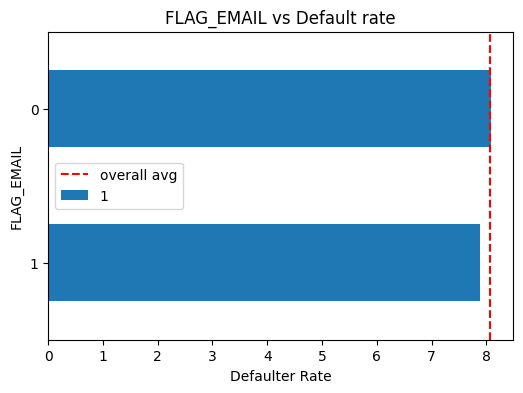


Columns : ORGANIZATION_TYPE
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University               

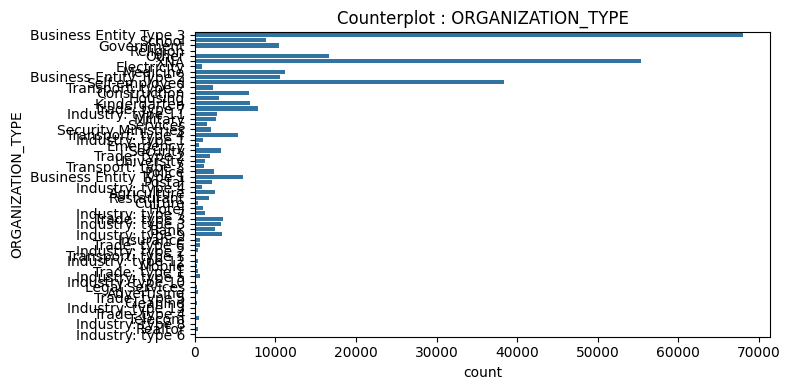

Relation with TARGET 
ORGANIZATION_TYPE
Advertising                8.16
Agriculture               10.47
Bank                       5.19
Business Entity Type 1     8.14
Business Entity Type 2     8.53
Business Entity Type 3     9.30
Cleaning                  11.15
Construction              11.68
Culture                    5.54
Electricity                6.63
Emergency                  7.14
Government                 6.98
Hotel                      6.42
Housing                    7.94
Industry: type 1          11.07
Industry: type 10          6.42
Industry: type 11          8.65
Industry: type 12          3.79
Industry: type 13         13.43
Industry: type 2           7.21
Industry: type 3          10.62
Industry: type 4          10.15
Industry: type 5           6.84
Industry: type 6           7.14
Industry: type 7           8.03
Industry: type 8          12.50
Industry: type 9           6.68
Insurance                  5.70
Kindergarten               7.03
Legal Services             7.87


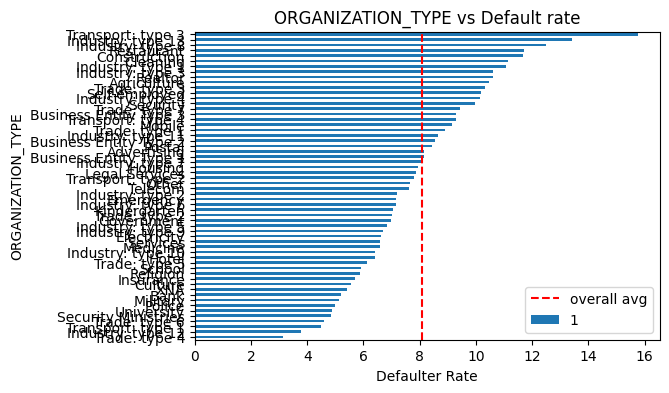

In [216]:
categorical_columns=["CODE_GENDER","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE","OCCUPATION_TYPE","NAME_CONTRACT_TYPE","FLAG_OWN_CAR","FLAG_OWN_REALTY","FLAG_EMP_PHONE","FLAG_PHONE","FLAG_EMAIL","ORGANIZATION_TYPE"]
for col in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Columns : {col}")
    print('='*60)

    print(df[col].value_counts())

    plt.figure(figsize=(8,4))
    sns.countplot(y=col,data=df)
    plt.title(f"Counterplot : {col}")
    plt.tight_layout()
    plt.show()

    print(f"Relation with TARGET ")
    cross=pd.crosstab(df[col],df["TARGET"],normalize='index')[1]*100
    print(cross.round(2))


    cross.sort_values().plot(kind="barh",figsize=(6,4))
    plt.xlabel("Defaulter Rate")
    plt.title(f"{col} vs Default rate")
    plt.axvline(df["TARGET"].mean()*100,color='red',linestyle='--',label="overall avg")
    plt.legend()
    plt.show()


Features : CNT_CHILDREN
count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64


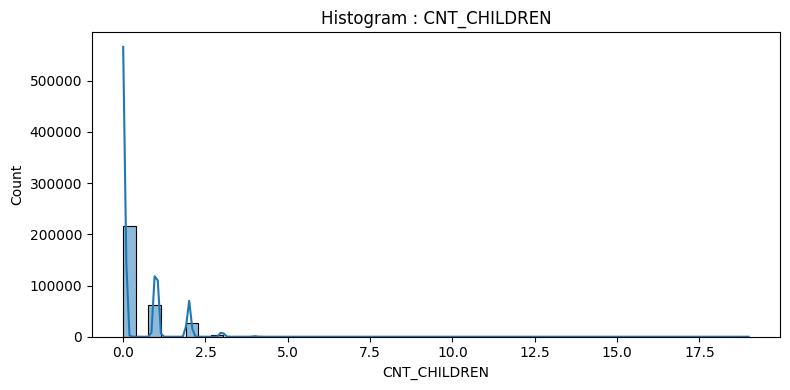

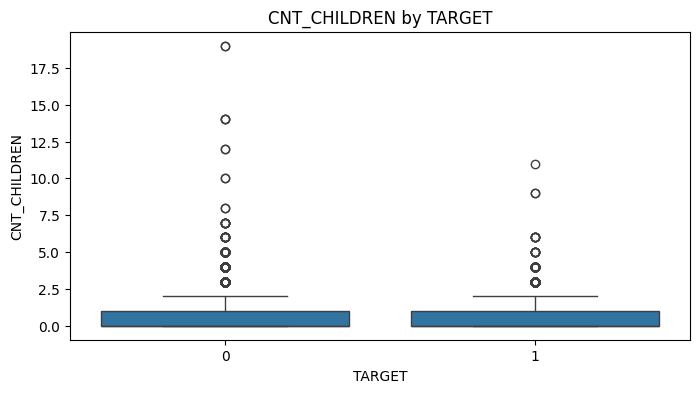


Features : AMT_INCOME_TOTAL
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64


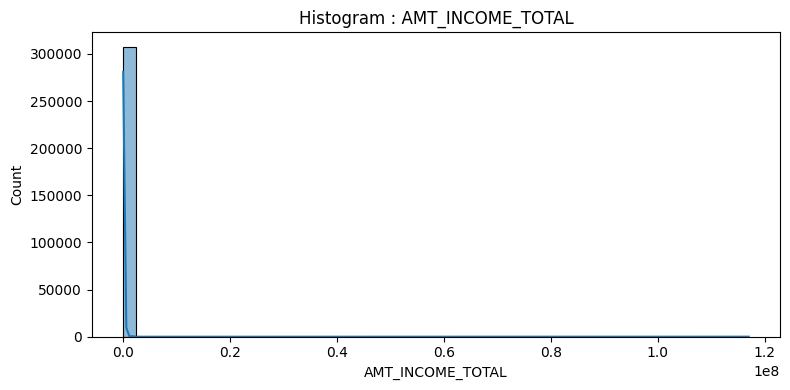

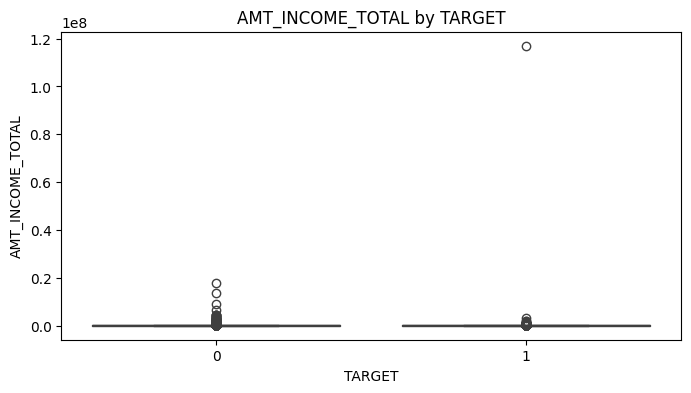


Features : DAYS_BIRTH
count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64


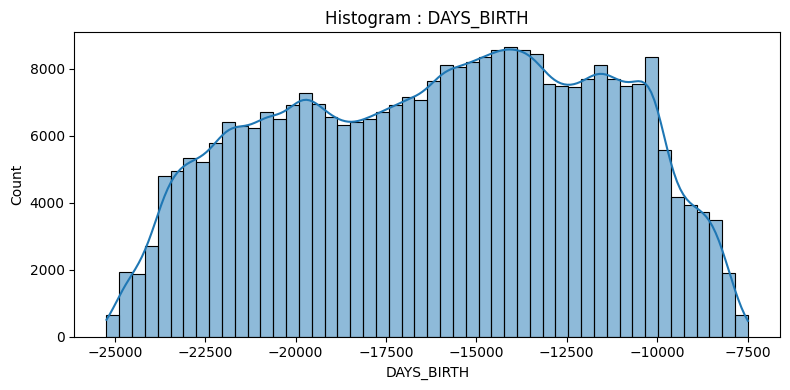

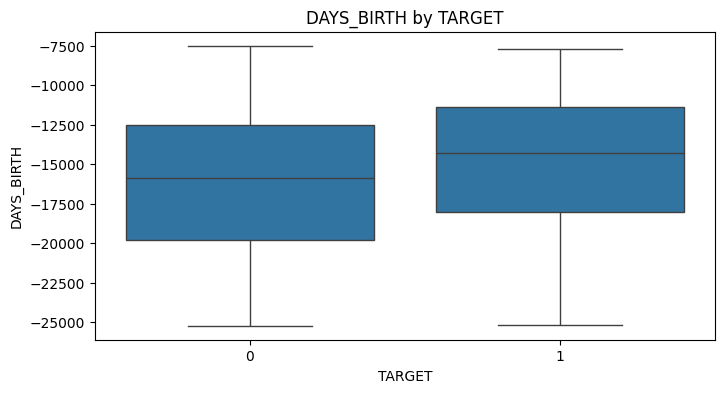


Features : DAYS_EMPLOYED
count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


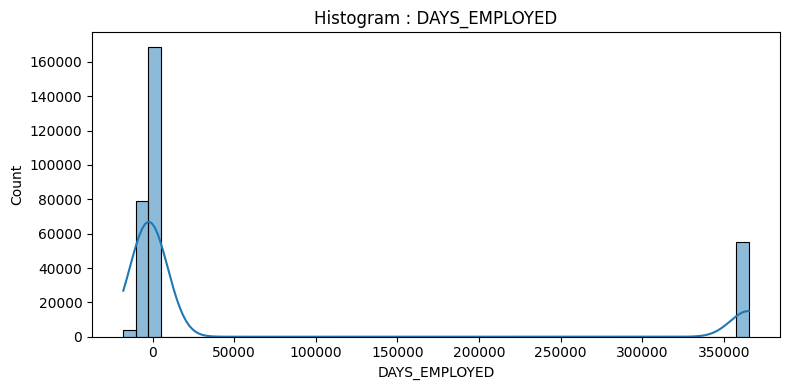

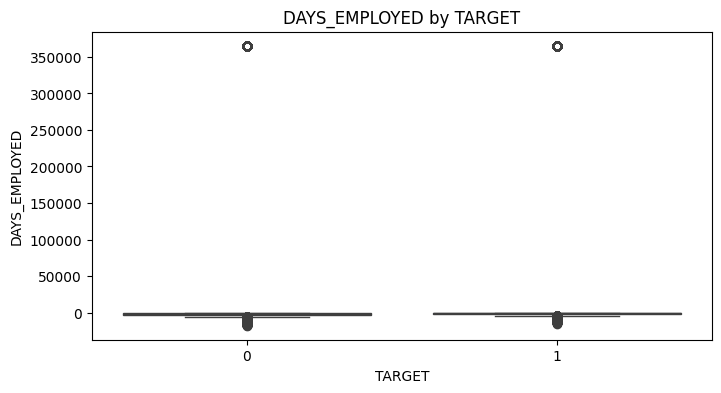


Features : CNT_FAM_MEMBERS
count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64


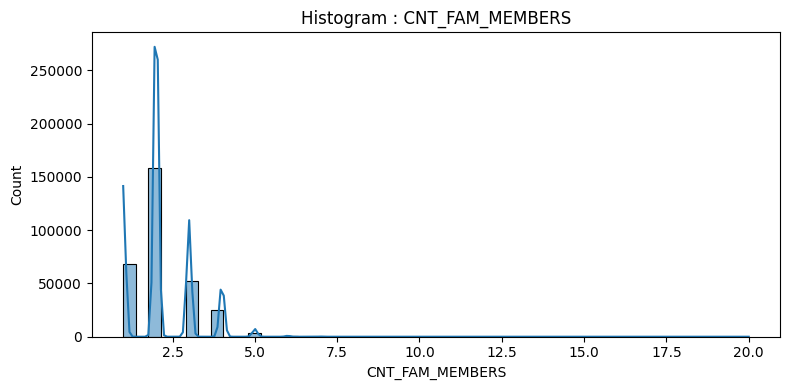

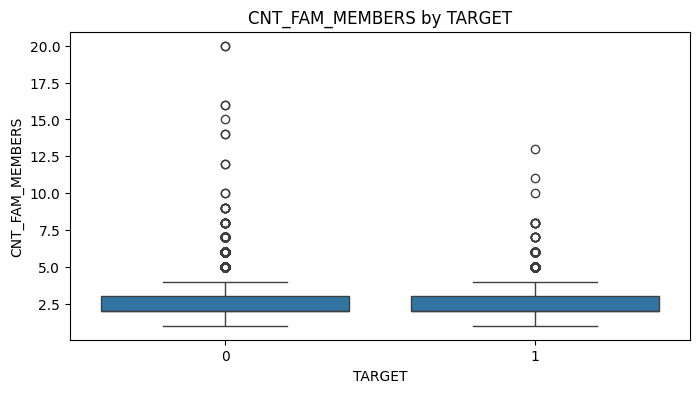


Features : AMT_CREDIT
count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64


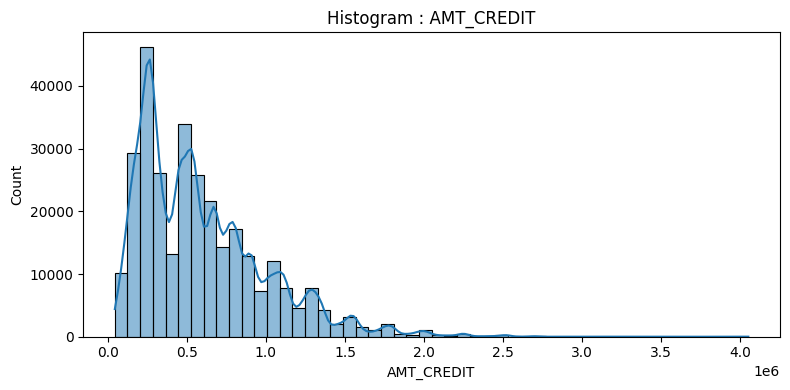

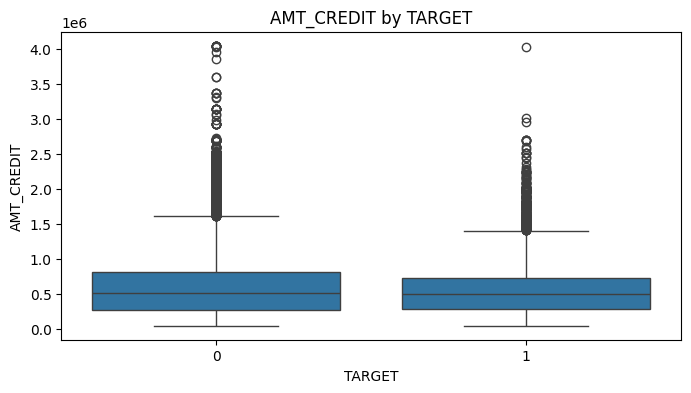


Features : AMT_ANNUITY
count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64


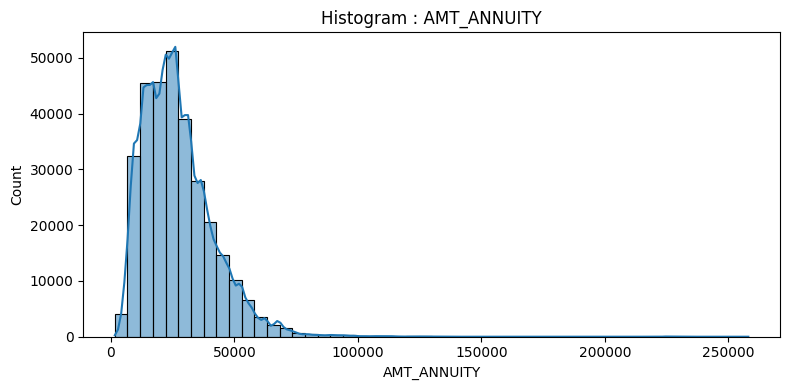

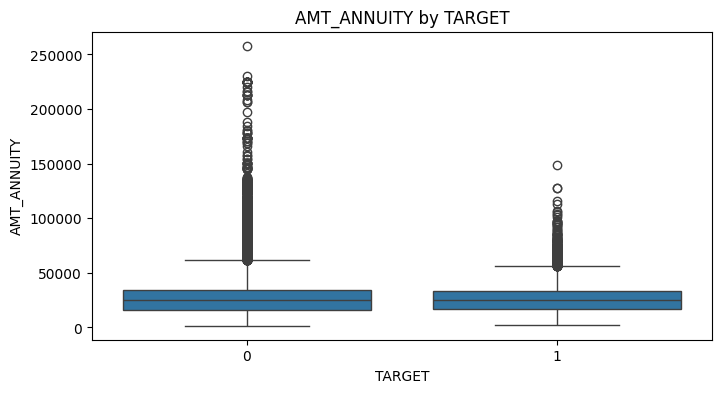


Features : AMT_GOODS_PRICE
count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64


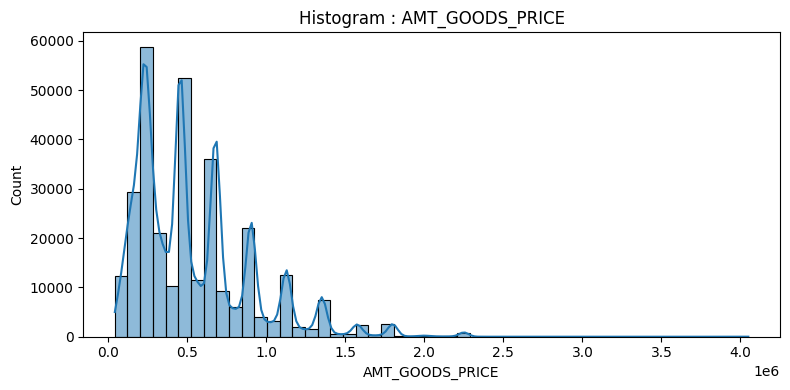

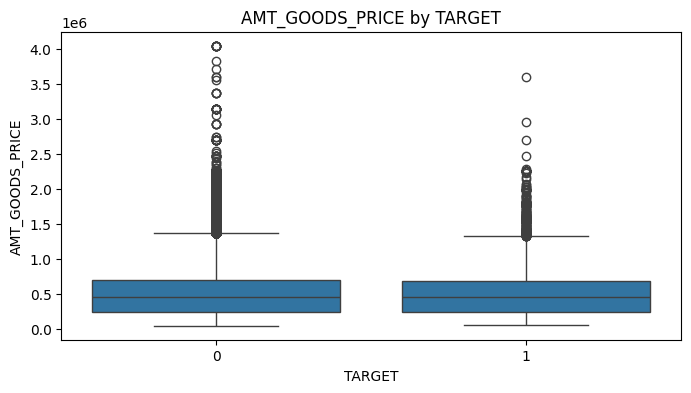


Features : OWN_CAR_AGE
count    104582.000000
mean         12.061091
std          11.944812
min           0.000000
25%           5.000000
50%           9.000000
75%          15.000000
max          91.000000
Name: OWN_CAR_AGE, dtype: float64


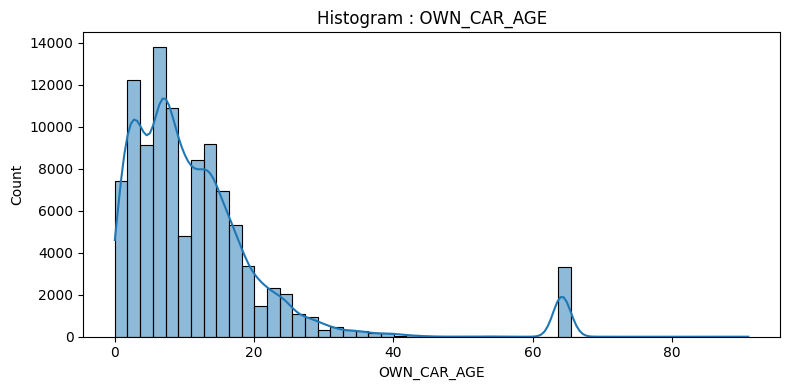

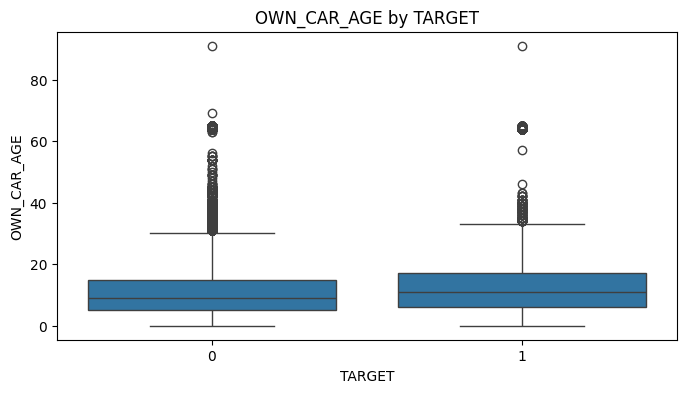


Features : EXT_SOURCE_1
count    134133.000000
mean          0.502130
std           0.211062
min           0.014568
25%           0.334007
50%           0.505998
75%           0.675053
max           0.962693
Name: EXT_SOURCE_1, dtype: float64


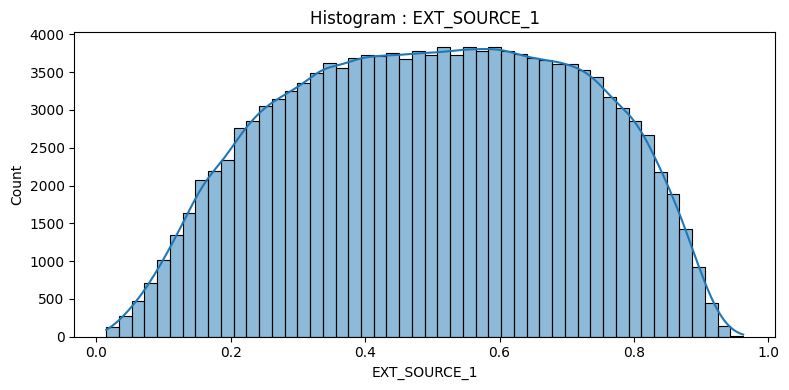

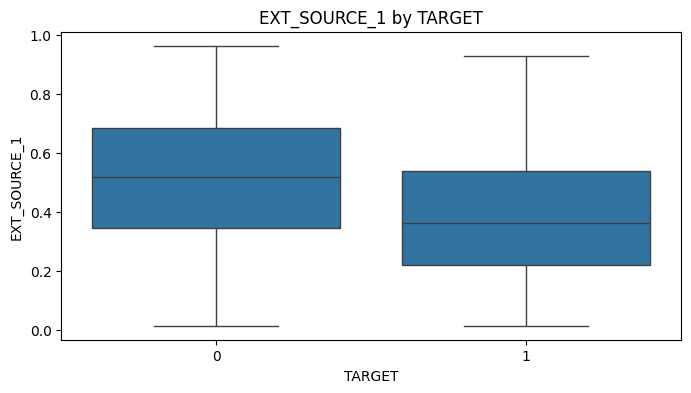


Features : EXT_SOURCE_2
count    3.068510e+05
mean     5.143927e-01
std      1.910602e-01
min      8.173617e-08
25%      3.924574e-01
50%      5.659614e-01
75%      6.636171e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64


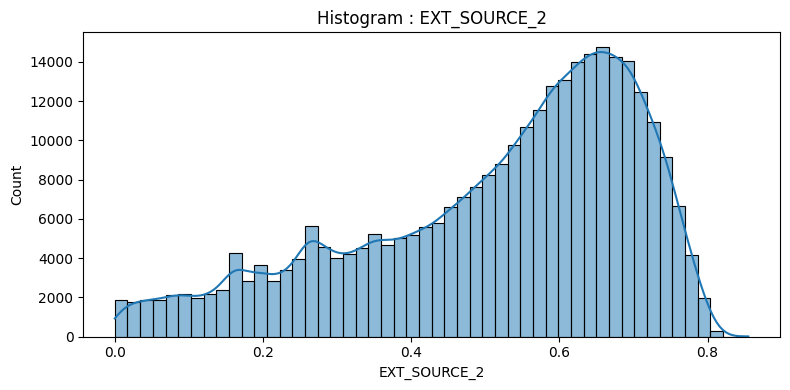

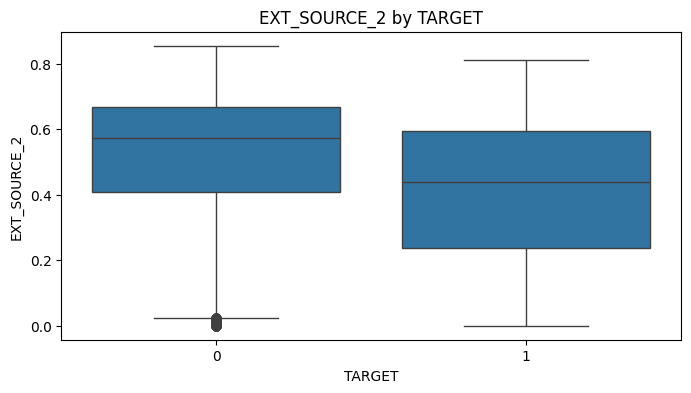


Features : EXT_SOURCE_3
count    246546.000000
mean          0.510853
std           0.194844
min           0.000527
25%           0.370650
50%           0.535276
75%           0.669057
max           0.896010
Name: EXT_SOURCE_3, dtype: float64


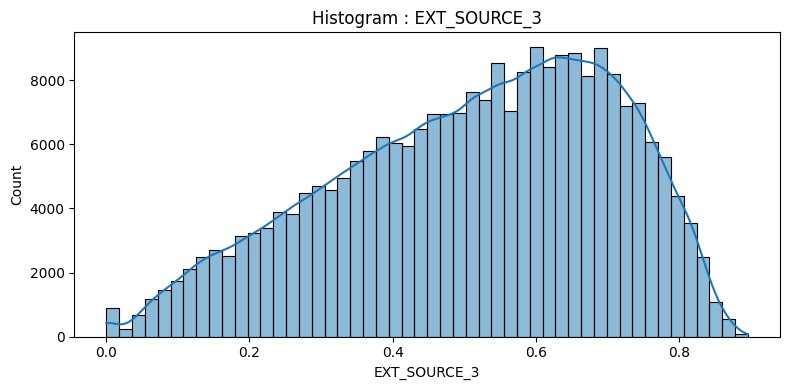

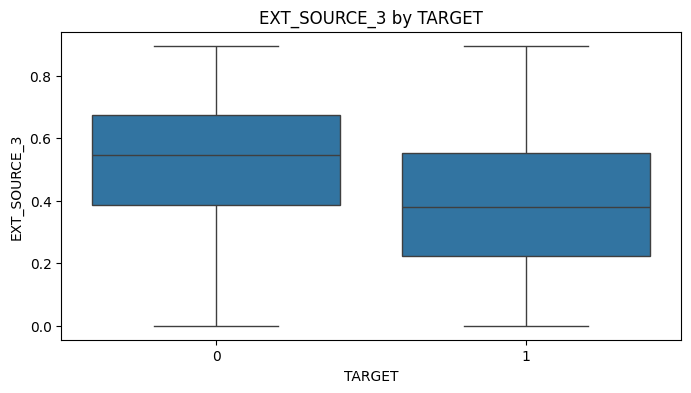


Features : REGION_RATING_CLIENT
count    307511.000000
mean          2.052463
std           0.509034
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: REGION_RATING_CLIENT, dtype: float64


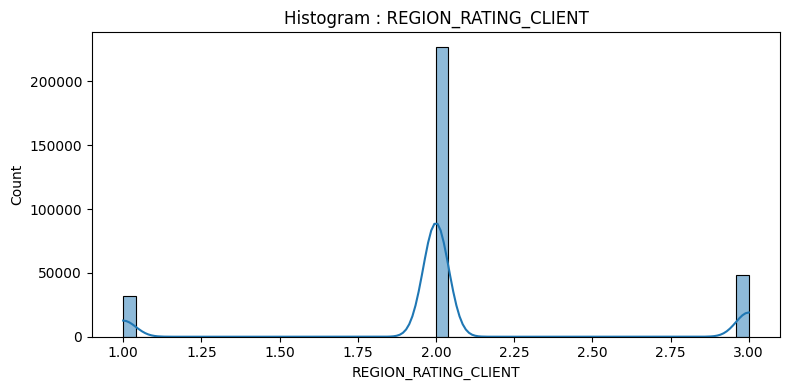

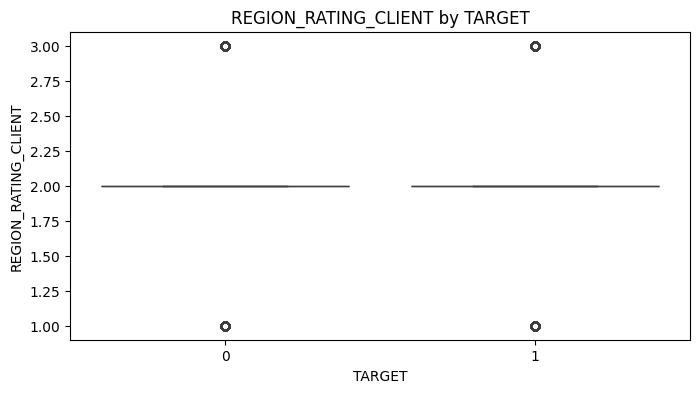


Features : REGION_RATING_CLIENT_W_CITY
count    307511.000000
mean          2.031521
std           0.502737
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: REGION_RATING_CLIENT_W_CITY, dtype: float64


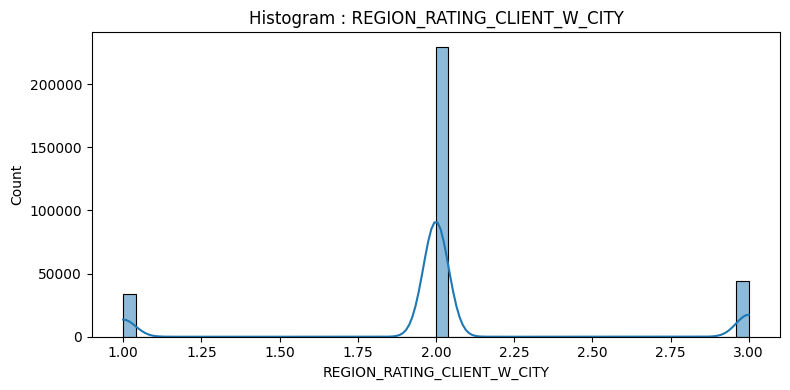

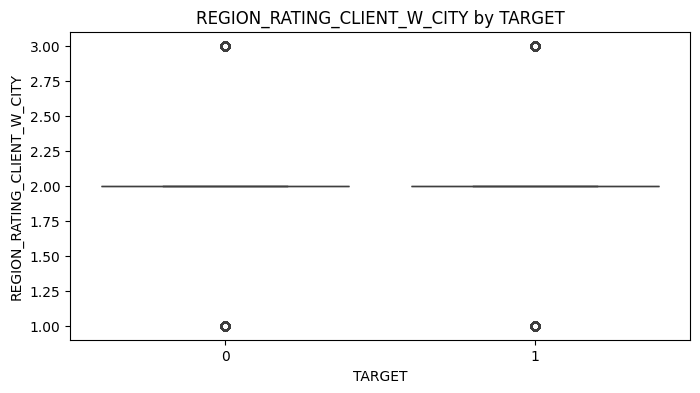


Features : REGION_POPULATION_RELATIVE
count    307511.000000
mean          0.020868
std           0.013831
min           0.000290
25%           0.010006
50%           0.018850
75%           0.028663
max           0.072508
Name: REGION_POPULATION_RELATIVE, dtype: float64


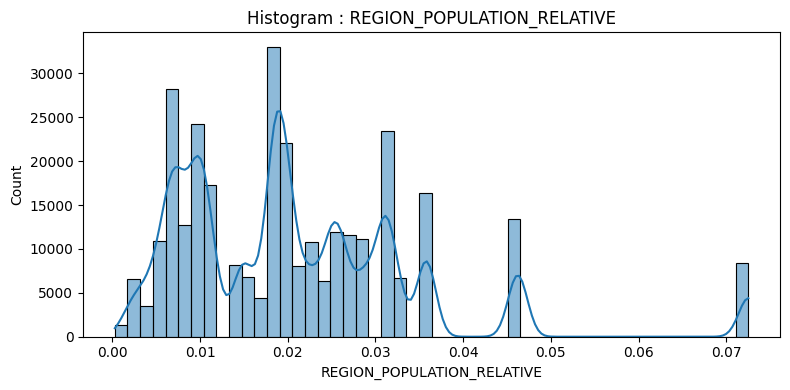

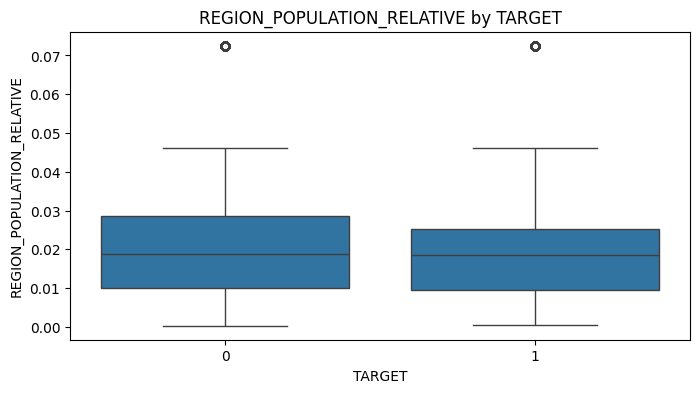


Features : DAYS_LAST_PHONE_CHANGE
count    307510.000000
mean       -962.858788
std         826.808487
min       -4292.000000
25%       -1570.000000
50%        -757.000000
75%        -274.000000
max           0.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64


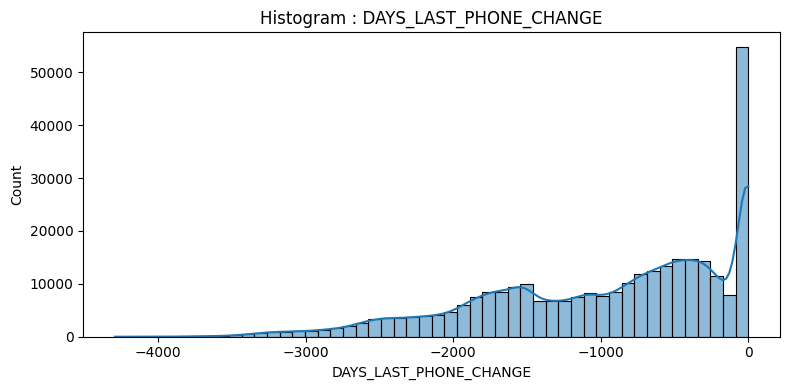

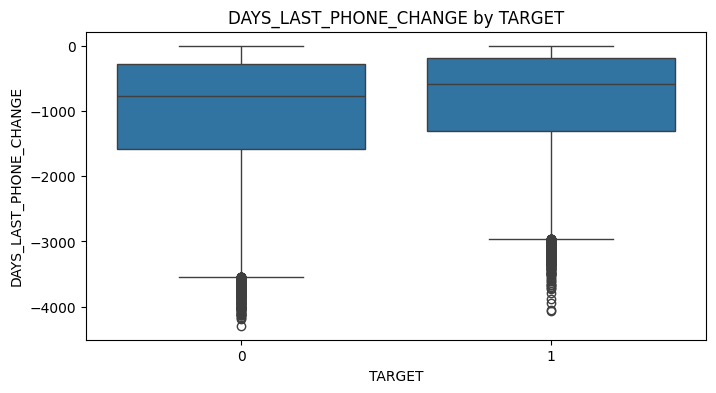

In [217]:
numerical_features=["CNT_CHILDREN","AMT_INCOME_TOTAL","DAYS_BIRTH","DAYS_EMPLOYED","CNT_FAM_MEMBERS","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","OWN_CAR_AGE",
"EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY","REGION_POPULATION_RELATIVE","DAYS_LAST_PHONE_CHANGE"]

for num in numerical_features:
    print(f"\n{'='*60}")
    print(f"Features : {num}")
    print("="*60)

    print(df[num].describe())

    plt.figure(figsize=(8,4))
    sns.histplot(df[num].dropna(),kde=True,bins=50)
    plt.title(f"Histogram : {num}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    sns.boxplot(x="TARGET",y=num,data=df)
    plt.title(f"{num} by TARGET")
    plt.show()


In [218]:
numerical_features=["CNT_CHILDREN","AMT_INCOME_TOTAL","DAYS_BIRTH","DAYS_EMPLOYED","CNT_FAM_MEMBERS","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","OWN_CAR_AGE",
"EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY","REGION_POPULATION_RELATIVE","DAYS_LAST_PHONE_CHANGE"]
comparison=df.groupby('TARGET')[numerical_features].mean().T
comparison.columns=["TARGET=0 (Repaid)","TARGET=1 (Default)"]
comparison["% Difference"]=((comparison["TARGET=1 (Default)"]-comparison["TARGET=0 (Repaid)"])/comparison["TARGET=0 (Repaid)"]*100).round(2)
print(comparison.sort_values('% Difference',key=abs,ascending=False))

                             TARGET=0 (Repaid)  TARGET=1 (Default)  \
DAYS_EMPLOYED                     65696.146123        42394.675448   
EXT_SOURCE_3                          0.520969            0.390717   
EXT_SOURCE_1                          0.511461            0.386968   
EXT_SOURCE_2                          0.523479            0.410935   
DAYS_LAST_PHONE_CHANGE             -976.388294         -808.796818   
OWN_CAR_AGE                          11.935540           13.668691   
CNT_CHILDREN                          0.412946            0.463807   
AMT_GOODS_PRICE                  542736.795003       488972.412554   
REGION_POPULATION_RELATIVE            0.021021            0.019131   
DAYS_BIRTH                       -16138.176397       -14884.828077   
AMT_CREDIT                       602648.282002       557778.527674   
REGION_RATING_CLIENT_W_CITY           2.022449            2.134824   
REGION_RATING_CLIENT                  2.043578            2.153635   
AMT_ANNUITY         

In [219]:
selected_features=["CODE_GENDER","NAME_INCOME_TYPE","NAME_EDUCATION_TYPE","NAME_FAMILY_STATUS",
"NAME_HOUSING_TYPE","OCCUPATION_TYPE","FLAG_OWN_CAR","FLAG_OWN_REALTY",
"ORGANIZATION_TYPE","CNT_CHILDREN","CNT_FAM_MEMBERS","AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","DAYS_BIRTH","DAYS_EMPLOYED","REGION_RATING_CLIENT","REGION_RATING_CLIENT_W_CITY",
"REGION_POPULATION_RELATIVE","EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3","DAYS_LAST_PHONE_CHANGE","TARGET"]
df=df[selected_features]


In [220]:
df.head()

,CODE_GENDER,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,FLAG_OWN_CAR,FLAG_OWN_REALTY,ORGANIZATION_TYPE,CNT_CHILDREN,...,DAYS_BIRTH,DAYS_EMPLOYED,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,REGION_POPULATION_RELATIVE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_LAST_PHONE_CHANGE,TARGET
0,M,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,N,Y,Business Entity Type 3,0,...,-9461,-637,2,2,0.018801,0.083037,0.262949,0.139376,-1134.0,1
1,F,State servant,Higher education,Married,House / apartment,Core staff,N,N,School,0,...,-16765,-1188,1,1,0.003541,0.311267,0.622246,NaN,-828.0,0
2,M,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,Y,Y,Government,0,...,-19046,-225,2,2,0.010032,NaN,0.555912,0.729567,-815.0,0
3,F,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,N,Y,Business Entity Type 3,0,...,-19005,-3039,2,2,0.008019,NaN,0.650442,NaN,-617.0,0
4,M,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,N,Y,Religion,0,...,-19932,-3038,2,2,0.028663,NaN,0.322738,NaN,-1106.0,0


In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   CODE_GENDER                  307511 non-null  object 
 1   NAME_INCOME_TYPE             307511 non-null  object 
 2   NAME_EDUCATION_TYPE          307511 non-null  object 
 3   NAME_FAMILY_STATUS           307511 non-null  object 
 4   NAME_HOUSING_TYPE            307511 non-null  object 
 5   OCCUPATION_TYPE              211120 non-null  object 
 6   FLAG_OWN_CAR                 307511 non-null  object 
 7   FLAG_OWN_REALTY              307511 non-null  object 
 8   ORGANIZATION_TYPE            307511 non-null  object 
 9   CNT_CHILDREN                 307511 non-null  int64  
 10  CNT_FAM_MEMBERS              307509 non-null  float64
 11  AMT_INCOME_TOTAL             307511 non-null  float64
 12  AMT_CREDIT                   307511 non-null  float64
 13 

In [222]:
X=df.drop("TARGET",axis=1)
y=df["TARGET"]

In [223]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [224]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [225]:
categorical=X.select_dtypes(include="object").columns
numerical=X.select_dtypes(exclude="object").columns

In [226]:
numerical_trans=Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_trans=Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

In [227]:
preprocessor=ColumnTransformer(transformers=[("num",numerical_trans,numerical),("cat",categorical_trans,categorical)])

In [228]:
from sklearn.linear_model import LogisticRegression

In [229]:
model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("classifier",LogisticRegression(class_weight="balanced",random_state=42,max_iter=1000))
    ]
)

In [230]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [231]:
y_pred=model.predict(X_test)

In [234]:
#logistic model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score
print("fi_score :",f1_score(y_test,y_pred))
print("accuracy_score :",accuracy_score(y_test,y_pred))
print("confusion_matrix :",confusion_matrix(y_test,y_pred))
print("recall :",recall_score(y_test,y_pred))
print("precision :",precision_score(y_test,y_pred))


fi_score : 0.2591462236816689
accuracy_score : 0.6881940718338942
confusion_matrix : [[38972 17566]
 [ 1611  3354]]
recall : 0.6755287009063444
precision : 0.16032504780114723


In [235]:
from sklearn.ensemble import RandomForestClassifier
models=Pipeline(
                steps=[
                ("preprocessor",preprocessor),
                ("classifier",RandomForestClassifier(class_weight="balanced",random_state=42,n_estimators=50,max_depth=10,n_jobs=-1))
                ]
                )

In [236]:
models.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [237]:
y_pred_rf=models.predict(X_test)

In [240]:
y_prob_rf=models.predict_proba(X_test)[:,1]

In [241]:
#random_forest evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score,roc_auc_score
print("fi_score :",f1_score(y_test,y_pred_rf))
print("accuracy_score :",accuracy_score(y_test,y_pred_rf))
print("confusion_matrix :",confusion_matrix(y_test,y_pred_rf))
print("recall :",recall_score(y_test,y_pred_rf))
print("precision :",precision_score(y_test,y_pred_rf))
print("roc_auc :",roc_auc_score(y_test,y_prob_rf))

fi_score : 0.2633779264214047
accuracy_score : 0.7135099100856869
confusion_matrix : [[40733 15805]
 [ 1815  3150]]
recall : 0.6344410876132931
precision : 0.16618306515431286


roc_auc : 0.7378931126965842


In [242]:
from xgboost import XGBClassifier
model_xb=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("classifier",XGBClassifier(scale_pos_weight=11,random_state=42,n_estimators=100,max_depth=6,eval_metric="logloss",learning_rate=0.1))
    ]
)

In [244]:
model_xb.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [245]:
y_pred_xb=model_xb.predict(X_test)

In [246]:
y_prob_xb=model_xb.predict_proba(X_test)[:,1]

In [247]:
#XGB  evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score,precision_score,roc_auc_score
print("fi_score :",f1_score(y_test,y_pred_xb))
print("accuracy_score :",accuracy_score(y_test,y_pred_xb))
print("confusion_matrix :",confusion_matrix(y_test,y_pred_xb))
print("recall :",recall_score(y_test,y_pred_xb))
print("precision :",precision_score(y_test,y_pred_xb))
print("roc_auc :",roc_auc_score(y_test,y_prob_xb))

fi_score : 0.27055237777128305
accuracy_score : 0.715932556135473
confusion_matrix : [[40792 15746]
 [ 1725  3240]]
recall : 0.6525679758308157
precision : 0.17065205941219846
roc_auc : 0.7544357907097177
